# Sleep Disorder Prediction

**Dataset:** 374 individuals with lifestyle, physiological, and occupational features.

**Two prediction tasks:**
- **Part A — Binary:** Does this person have any sleep disorder? (`0 = None`, `1 = Disorder`)
- **Part B — Multiclass:** Which disorder? (`0 = None`, `1 = Insomnia`, `2 = Sleep Apnea`)

**Challenges:**
- Small dataset (374 rows) — cross-validation is critical; held-out test set will be small
- Moderate class imbalance — None (~59%) vs. Insomnia (~21%) vs. Sleep Apnea (~21%)
- `Blood Pressure` stored as string — needs parsing
- `BMI Category` has duplicate labels (`Normal` and `Normal Weight`) — needs consolidation

**Models:** Logistic Regression (baseline), Random Forest, XGBoost — all with `class_weight='balanced'`

## 1. Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier

from xgboost import XGBClassifier

import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

## 2. Load Data

In [4]:
df = pd.read_csv('data/Sleep_health_and_lifestyle_dataset.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 49.2 KB


## 3. Data Cleaning

In [6]:
df = df.drop(columns=['Person ID'])

# NaN in Sleep Disorder means no disorder — fill explicitly
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# 'Normal Weight' and 'Normal' are the same category — consolidate
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

# Split Blood Pressure string 'systolic/diastolic' into two numeric columns
df[['BP Systolic', 'BP Diastolic']] = (
    df['Blood Pressure'].str.split('/', expand=True).astype(int)
)
df = df.drop(columns=['Blood Pressure'])

print('Cleaned shape:', df.shape)
print('\nSleep Disorder distribution:')
print(df['Sleep Disorder'].value_counts())
print('\nBMI Category distribution:')
print(df['BMI Category'].value_counts())
print('\nRemaining nulls:', df.isnull().sum().sum())

Cleaned shape: (374, 13)

Sleep Disorder distribution:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

BMI Category distribution:
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

Remaining nulls: 0


## 4. Exploratory Data Analysis

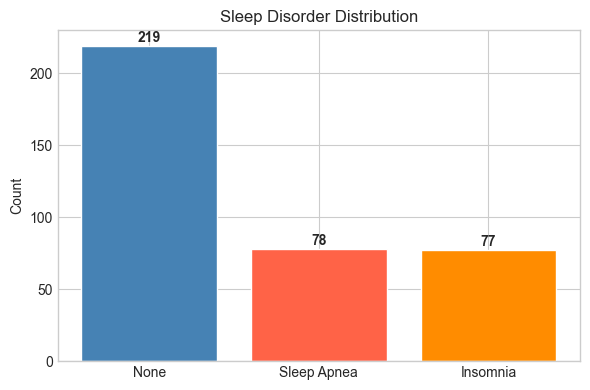

In [ ]:
# Target distribution 
disorder_counts = df['Sleep Disorder'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(disorder_counts.index, disorder_counts.values,
    color=['steelblue', 'tomato', 'darkorange'], edgecolor='white')
ax.set_title('Sleep Disorder Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(disorder_counts.values):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

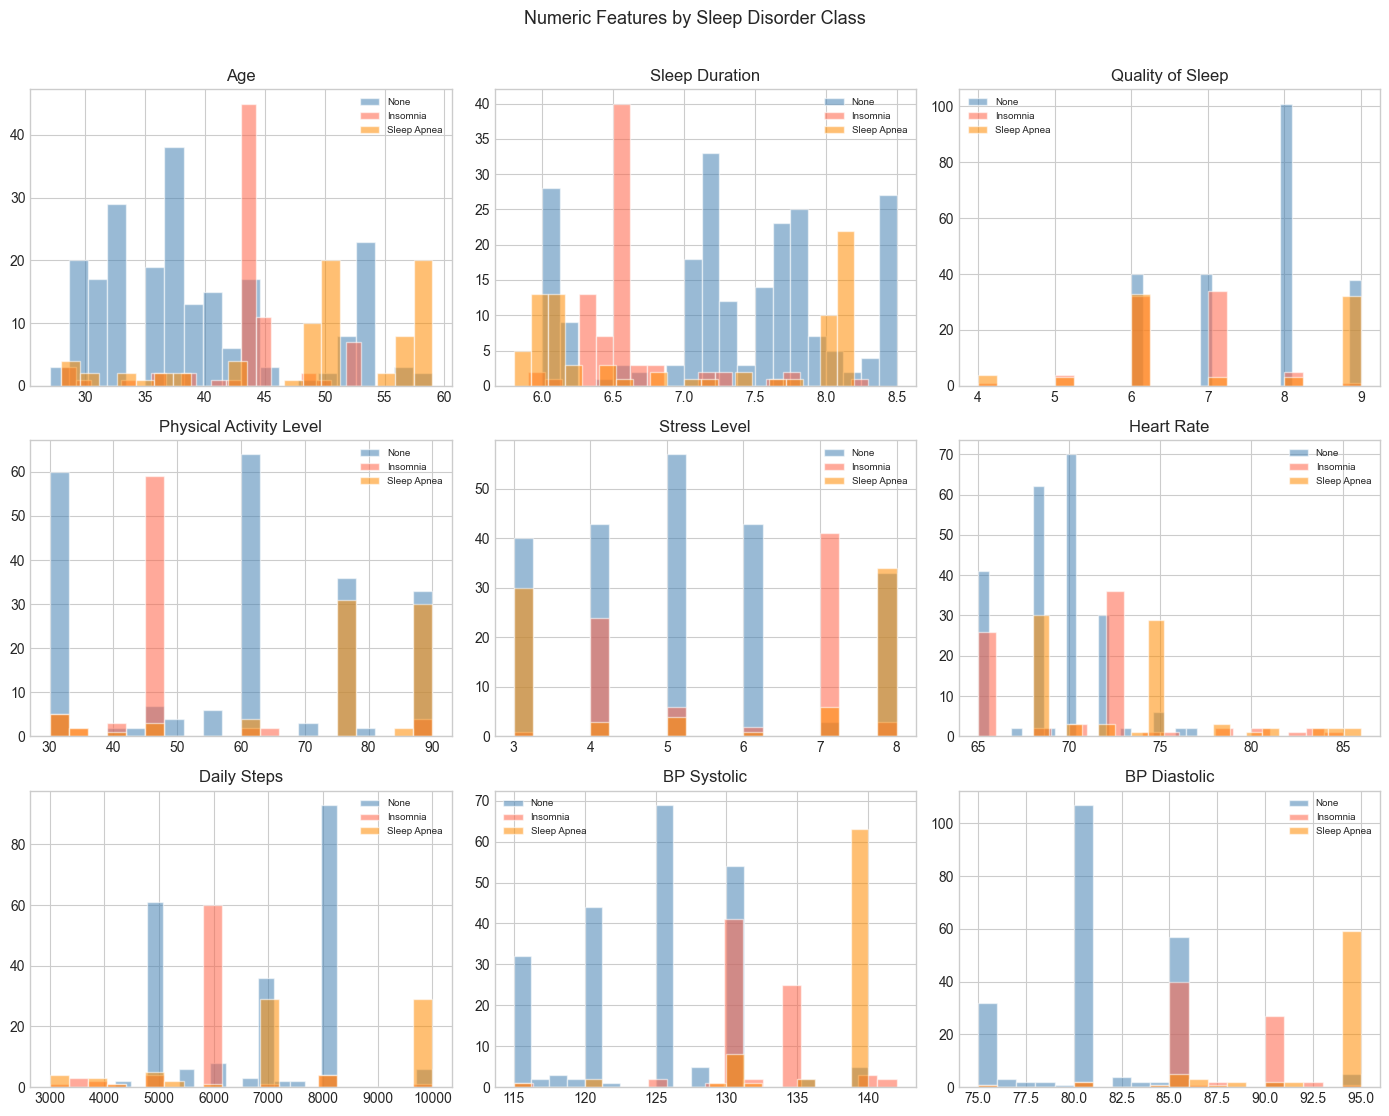

In [ ]:
# Numeric feature distributions by disorder class 
numeric_features = [
    'Age', 'Sleep Duration', 'Quality of Sleep',
    'Physical Activity Level', 'Stress Level',
    'Heart Rate', 'Daily Steps', 'BP Systolic', 'BP Diastolic'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
colors = {'None': 'steelblue', 'Insomnia': 'tomato', 'Sleep Apnea': 'darkorange'}

for ax, col in zip(axes.flatten(), numeric_features):
    for label, color in colors.items():
        subset = df[df['Sleep Disorder'] == label][col]
        ax.hist(subset, bins=20, alpha=0.55, color=color, label=label, edgecolor='white')
    ax.set_title(col)
    ax.legend(fontsize=7)

plt.suptitle('Numeric Features by Sleep Disorder Class', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

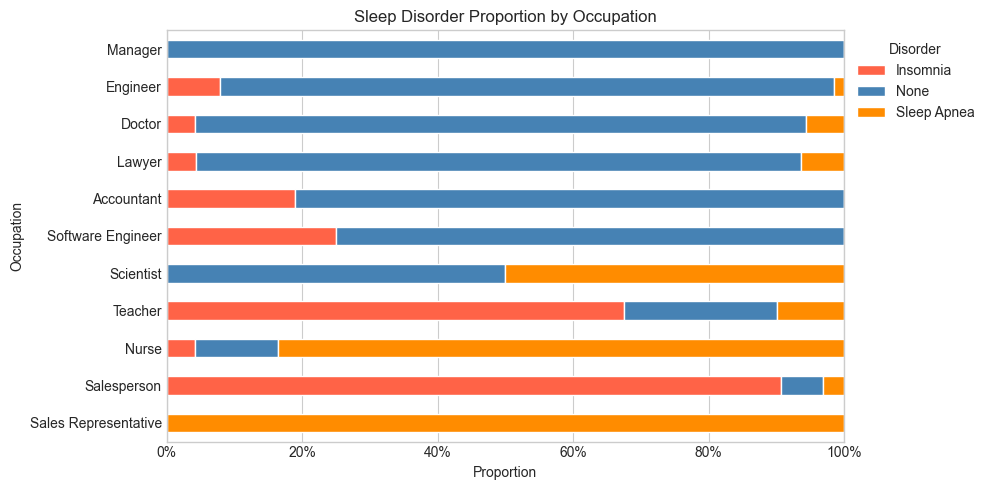

In [ ]:
# Sleep disorder rate by occupation
occ_disorder = (
    df.groupby('Occupation')['Sleep Disorder']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .sort_values('None', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
occ_disorder.plot(kind='barh', stacked=True, ax=ax,
                color=['tomato', 'steelblue', 'darkorange'], edgecolor='white')
ax.set_title('Sleep Disorder Proportion by Occupation')
ax.set_xlabel('Proportion')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(title='Disorder', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

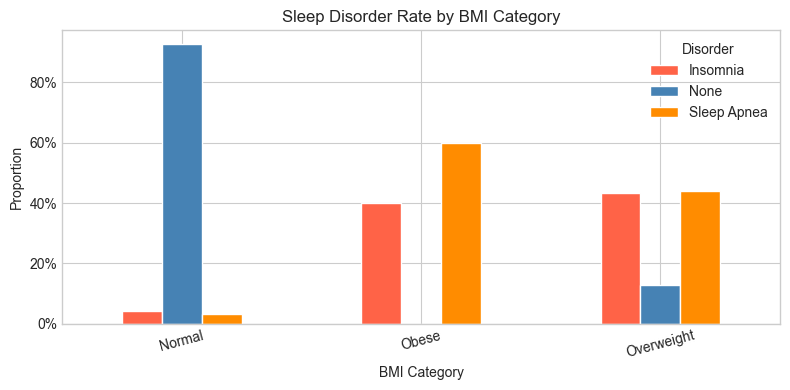

In [ ]:
# BMI Category vs Sleep Disorder 
bmi_disorder = (
    df.groupby('BMI Category')['Sleep Disorder']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 4))
bmi_disorder.plot(kind='bar', ax=ax,
                color=['tomato', 'steelblue', 'darkorange'], edgecolor='white')
ax.set_title('Sleep Disorder Rate by BMI Category')
ax.set_ylabel('Proportion')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Disorder', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

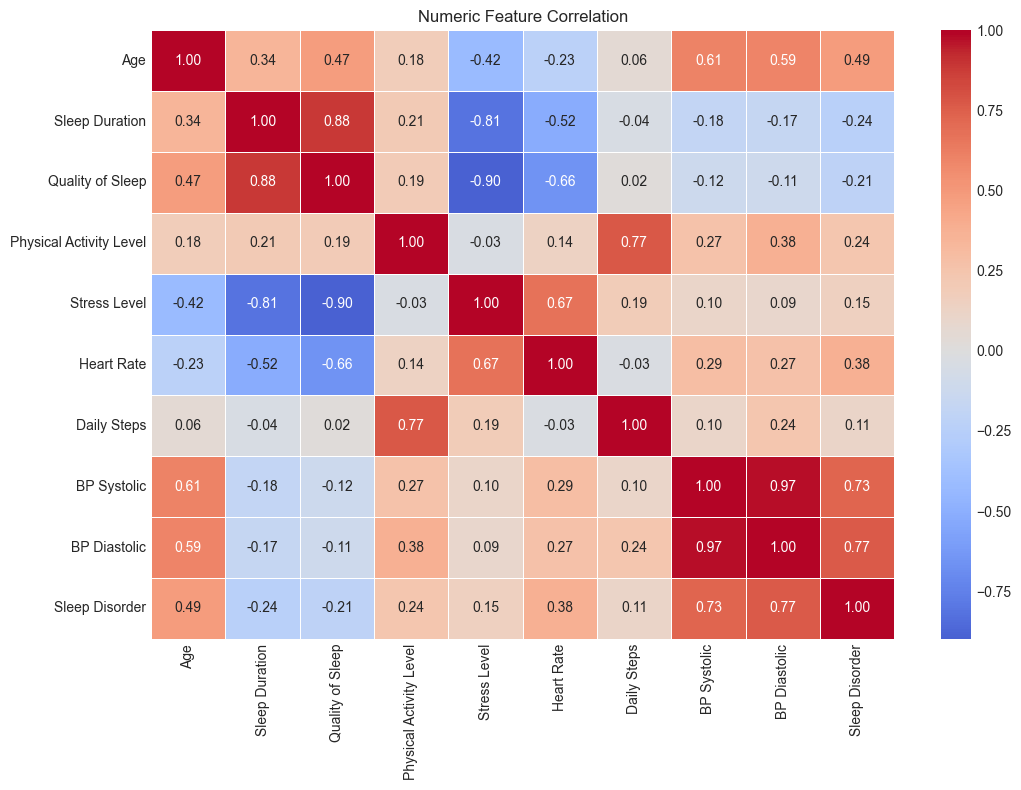

In [ ]:
# Correlation heatmap 
numeric_df = df[numeric_features].copy()

# Encode target numerically just for correlation view
disorder_map = {'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2}
numeric_df['Sleep Disorder'] = df['Sleep Disorder'].map(disorder_map)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    numeric_df.corr(), annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax, linewidths=0.5
)
ax.set_title('Numeric Feature Correlation')
plt.tight_layout()
plt.show()

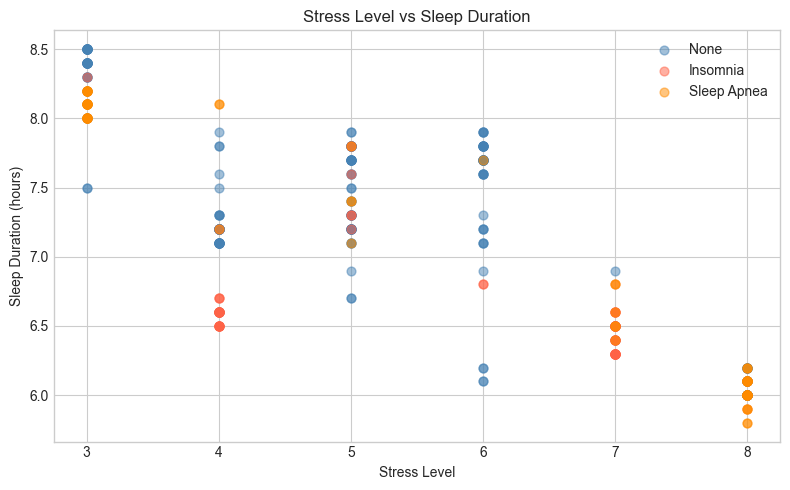

In [ ]:
# Stress Level vs Sleep Duration scatter by disorder
fig, ax = plt.subplots(figsize=(8, 5))
for label, color in colors.items():
    subset = df[df['Sleep Disorder'] == label]
    ax.scatter(subset['Stress Level'], subset['Sleep Duration'],
            alpha=0.5, s=40, color=color, label=label)
ax.set_title('Stress Level vs Sleep Duration')
ax.set_xlabel('Stress Level')
ax.set_ylabel('Sleep Duration (hours)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [ ]:
df_fe = df.copy()

#  Binary encoding 
df_fe['Gender'] = (df_fe['Gender'] == 'Male').astype(int)

# Ordinal encoding for BMI (meaningful order: Normal < Overweight < Obese) 
bmi_order = {'Normal': 0, 'Overweight': 1, 'Obese': 2}
df_fe['BMI Category'] = df_fe['BMI Category'].map(bmi_order)

# One-hot encode Occupation (no ordinal relationship between jobs) 
# Consolidate sparse occupations: Software Engineer, Scientist,
# Sales Representative, Manager → 'Other' to avoid rare dummy columns
sparse_jobs = ['Software Engineer', 'Scientist', 'Sales Representative', 'Manager']
df_fe['Occupation'] = df_fe['Occupation'].replace(
    {job: 'Other' for job in sparse_jobs}
)
df_fe = pd.get_dummies(df_fe, columns=['Occupation'], drop_first=False)

# Engineered features 

# Sleep efficiency proxy: quality relative to duration
# High quality per hour = efficient sleeper; low = fragmented or disturbed
df_fe['sleep_efficiency'] = df_fe['Quality of Sleep'] / df_fe['Sleep Duration']

# Pulse pressure: systolic - diastolic. Elevated PP is linked to cardiovascular
# and sleep issues; more informative than either pressure reading alone
df_fe['pulse_pressure'] = df_fe['BP Systolic'] - df_fe['BP Diastolic']

# Hypertension flag: systolic >= 130 or diastolic >= 85 (Stage 1 threshold)
df_fe['hypertension_flag'] = (
    (df_fe['BP Systolic'] >= 130) | (df_fe['BP Diastolic'] >= 85)
).astype(int)

# Active lifestyle flag: above-median steps AND above-median physical activity
step_med = df_fe['Daily Steps'].median()
activity_med = df_fe['Physical Activity Level'].median()
df_fe['active_lifestyle'] = (
    (df_fe['Daily Steps'] > step_med) &
    (df_fe['Physical Activity Level'] > activity_med)
).astype(int)

# High stress + short sleep: a compound risk indicator for sleep disorders
stress_med = df_fe['Stress Level'].median()
sleep_med = df_fe['Sleep Duration'].median()
df_fe['stress_sleep_risk'] = (
    (df_fe['Stress Level'] > stress_med) &
    (df_fe['Sleep Duration'] < sleep_med)
).astype(int)

print(f'Features after engineering: {df_fe.shape[1] - 1}')
df_fe.head()

Features after engineering: 24


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,...,Occupation_Lawyer,Occupation_Nurse,Occupation_Other,Occupation_Salesperson,Occupation_Teacher,sleep_efficiency,pulse_pressure,hypertension_flag,active_lifestyle,stress_sleep_risk
0,1,27,6.1,6,42,6,1,77,4200,None,...,False,False,True,False,False,0.983607,43,0,0,1
1,1,28,6.2,6,60,8,0,75,10000,None,...,False,False,False,False,False,0.967742,45,0,0,1
2,1,28,6.2,6,60,8,0,75,10000,None,...,False,False,False,False,False,0.967742,45,0,0,1
3,1,28,5.9,4,30,8,2,85,3000,Sleep Apnea,...,False,False,True,False,False,0.677966,50,1,0,1
4,1,28,5.9,4,30,8,2,85,3000,Sleep Apnea,...,False,False,True,False,False,0.677966,50,1,0,1


## 6. Target Encoding

Two separate targets are derived from the same engineered feature set.

In [14]:
# Binary target: any disorder vs. none
y_binary = (df_fe['Sleep Disorder'] != 'None').astype(int)

# Multiclass target: None=0, Insomnia=1, Sleep Apnea=2
multiclass_map = {'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2}
y_multi = df_fe['Sleep Disorder'].map(multiclass_map)

X = df_fe.drop(columns=['Sleep Disorder'])

print('Binary target distribution:')
print(y_binary.value_counts().rename({0: 'No Disorder', 1: 'Disorder'}))
print(f'\nMulticlass target distribution:')
print(y_multi.value_counts().rename({0: 'None', 1: 'Insomnia', 2: 'Sleep Apnea'}))
print(f'\nFeature matrix shape: {X.shape}')

assert X.select_dtypes(include='object').shape[1] == 0, "Non-numeric columns remain"

Binary target distribution:
Sleep Disorder
No Disorder    219
Disorder       155
Name: count, dtype: int64

Multiclass target distribution:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

Feature matrix shape: (374, 24)


## 7. Train/Test Split

In [15]:
# Single split used for both tasks to keep test sets identical
# Stratify on multiclass target — this preserves both binary and multiclass ratios
X_train, X_test, y_bin_train, y_bin_test, y_multi_train, y_multi_test = train_test_split(
    X, y_binary, y_multi,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_multi
)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'\nTest binary dist: {y_bin_test.value_counts().to_dict()}')
print(f'Test multi dist:  {y_multi_test.value_counts().to_dict()}')

Train: 299 rows | Test: 75 rows

Test binary dist: {0: 44, 1: 31}
Test multi dist:  {0: 44, 2: 16, 1: 15}


---
# Part A — Binary Classification: Disorder vs. No Disorder

In [28]:
def evaluate_binary(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    roc = roc_auc_score(y_te, y_prob)
    pr_auc = average_precision_score(y_te, y_prob)

    print(f'[Binary] {name}')
    print(f'ROC-AUC : {roc:.4f}')
    print(f'PR-AUC  : {pr_auc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['No Disorder', 'Disorder']))

    return model, y_pred, y_prob, roc, pr_auc

### 1 Logistic Regression

In [29]:
lr_bin = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

lr_bin_model, lr_bin_pred, lr_bin_prob, lr_bin_roc, lr_bin_pr = evaluate_binary(
    'Logistic Regression', lr_bin, X_train, y_bin_train, X_test, y_bin_test
)

[Binary] Logistic Regression
ROC-AUC : 0.9938
PR-AUC  : 0.9904
              precision    recall  f1-score   support

 No Disorder       1.00      0.91      0.95        44
    Disorder       0.89      1.00      0.94        31

    accuracy                           0.95        75
   macro avg       0.94      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75



### 2 Random Forest

In [30]:
rf_bin = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_bin_model, rf_bin_pred, rf_bin_prob, rf_bin_roc, rf_bin_pr = evaluate_binary(
    'Random Forest', rf_bin, X_train, y_bin_train, X_test, y_bin_test
)

[Binary] Random Forest
ROC-AUC : 0.9857
PR-AUC  : 0.9697
              precision    recall  f1-score   support

 No Disorder       1.00      0.98      0.99        44
    Disorder       0.97      1.00      0.98        31

    accuracy                           0.99        75
   macro avg       0.98      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



### 3 XGBoost

In [31]:
neg = (y_bin_train == 0).sum()
pos = (y_bin_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight: {spw:.2f}')

xgb_bin = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_bin_model, xgb_bin_pred, xgb_bin_prob, xgb_bin_roc, xgb_bin_pr = evaluate_binary(
    'XGBoost', xgb_bin, X_train, y_bin_train, X_test, y_bin_test
)

scale_pos_weight: 1.41
[Binary] XGBoost
ROC-AUC : 0.9908
PR-AUC  : 0.9839
              precision    recall  f1-score   support

 No Disorder       1.00      0.98      0.99        44
    Disorder       0.97      1.00      0.98        31

    accuracy                           0.99        75
   macro avg       0.98      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



### 4 Binary — Comparison Plots

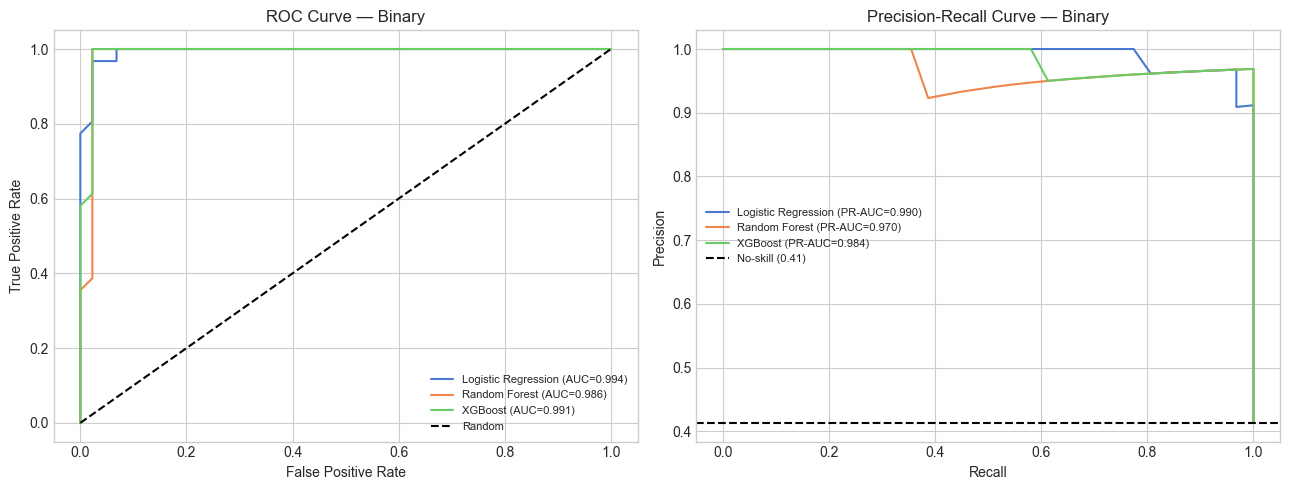

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bin_models_info = [
    ('Logistic Regression', lr_bin_prob, lr_bin_roc, lr_bin_pr),
    ('Random Forest', rf_bin_prob, rf_bin_roc, rf_bin_pr),
    ('XGBoost', xgb_bin_prob, xgb_bin_roc, xgb_bin_pr),
]

ax1, ax2 = axes

for name, prob, roc, pr in bin_models_info:
    fpr, tpr, _ = roc_curve(y_bin_test, prob)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={roc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_title('ROC Curve — Binary')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(fontsize=8)

for name, prob, roc, pr in bin_models_info:
    prec, rec, _ = precision_recall_curve(y_bin_test, prob)
    ax2.plot(rec, prec, label=f'{name} (PR-AUC={pr:.3f})')
ax2.axhline(y_bin_test.mean(), color='k', linestyle='--',
            label=f'No-skill ({y_bin_test.mean():.2f})')
ax2.set_title('Precision-Recall Curve — Binary')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

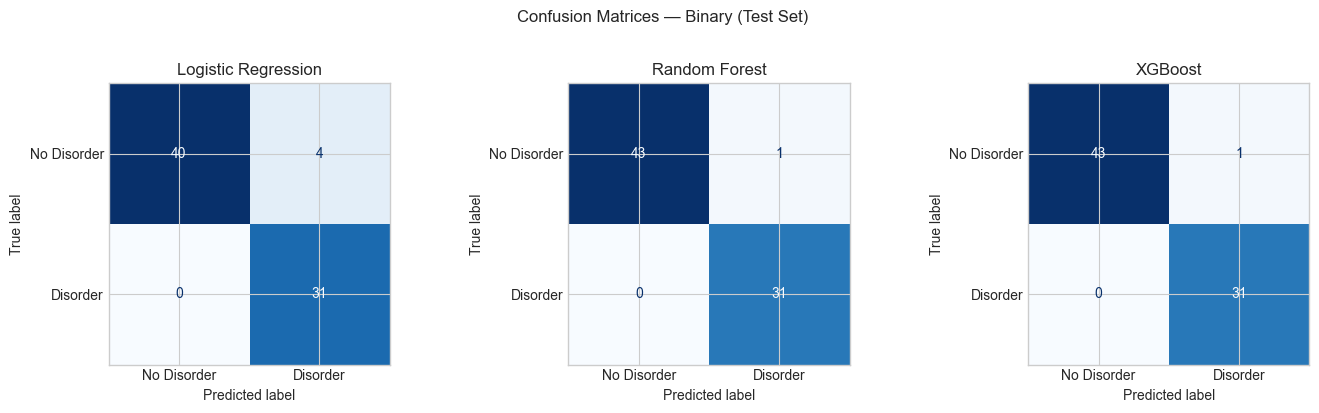

In [ ]:
# Confusion matrices 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pred) in zip(axes, [
    ('Logistic Regression', lr_bin_pred),
    ('Random Forest', rf_bin_pred),
    ('XGBoost', xgb_bin_pred),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_bin_test, pred),
        display_labels=['No Disorder', 'Disorder']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices — Binary (Test Set)', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Summary table 
bin_results = []
for name, pred, prob in [
    ('Logistic Regression', lr_bin_pred, lr_bin_prob),
    ('Random Forest', rf_bin_pred, rf_bin_prob),
    ('XGBoost', xgb_bin_pred, xgb_bin_prob),
]:
    bin_results.append({
        'Model': name,
        'Precision': precision_score(y_bin_test, pred),
        'Recall': recall_score(y_bin_test, pred),
        'F1': f1_score(y_bin_test, pred),
        'ROC-AUC': roc_auc_score(y_bin_test, prob),
        'PR-AUC': average_precision_score(y_bin_test, prob),
    })

print('Binary Classification Results:')
pd.DataFrame(bin_results).set_index('Model').round(4)

Binary Classification Results:


,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,
Logistic Regression,0.8857,1.0,0.9394,0.9938,0.9904
Random Forest,0.9688,1.0,0.9841,0.9857,0.9697
XGBoost,0.9688,1.0,0.9841,0.9908,0.9839


### 5 Binary — Threshold Tuning

Best threshold: 0.43
  Precision: 0.9688 | Recall: 1.0000 | F1: 0.9841


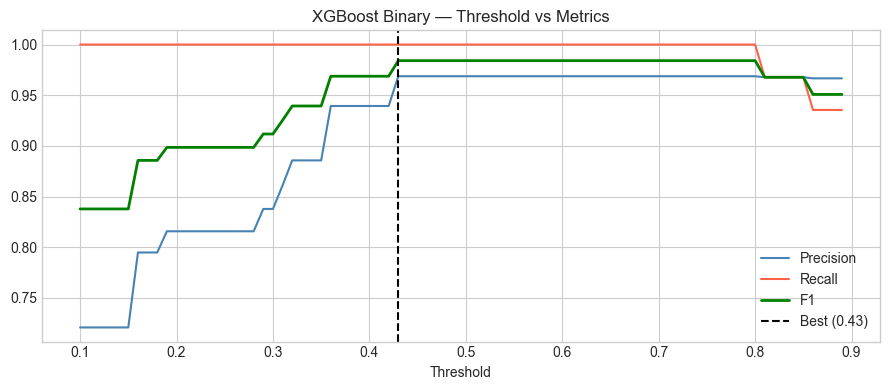


Final report at threshold=0.43:
              precision    recall  f1-score   support

 No Disorder       1.00      0.98      0.99        44
    Disorder       0.97      1.00      0.98        31

    accuracy                           0.99        75
   macro avg       0.98      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



In [23]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1s, precs, recs = [], [], []

for t in thresholds:
    p = (xgb_bin_prob >= t).astype(int)
    f1s.append(f1_score(y_bin_test, p, zero_division=0))
    precs.append(precision_score(y_bin_test, p, zero_division=0))
    recs.append(recall_score(y_bin_test, p, zero_division=0))

best_idx = np.argmax(f1s)
best_t = thresholds[best_idx]

print(f'Best threshold: {best_t:.2f}')
print(f'  Precision: {precs[best_idx]:.4f} | Recall: {recs[best_idx]:.4f} | F1: {f1s[best_idx]:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precs, label='Precision', color='steelblue')
ax.plot(thresholds, recs, label='Recall', color='tomato')
ax.plot(thresholds, f1s, label='F1', color='green', linewidth=2)
ax.axvline(best_t, color='black', linestyle='--', label=f'Best ({best_t:.2f})')
ax.set_title('XGBoost Binary — Threshold vs Metrics')
ax.set_xlabel('Threshold')
ax.legend()
plt.tight_layout()
plt.show()

final_bin_preds = (xgb_bin_prob >= best_t).astype(int)
print(f'\nFinal report at threshold={best_t:.2f}:')
print(classification_report(y_bin_test, final_bin_preds, target_names=['No Disorder', 'Disorder']))

### 6 Binary — Cross-Validation

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_xgb_bin = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric='aucpr',
    random_state=RANDOM_STATE, verbosity=0
)

cv_roc_bin = cross_val_score(cv_xgb_bin, X_train, y_bin_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_pr_bin  = cross_val_score(cv_xgb_bin, X_train, y_bin_train, cv=cv, scoring='average_precision', n_jobs=-1)

print('[Binary] 5-Fold CV — XGBoost')
print(f'  ROC-AUC: {cv_roc_bin.mean():.4f} ± {cv_roc_bin.std():.4f} | Folds: {cv_roc_bin.round(4)}')
print(f'  PR-AUC:  {cv_pr_bin.mean():.4f} ± {cv_pr_bin.std():.4f}  | Folds: {cv_pr_bin.round(4)}')

[Binary] 5-Fold CV — XGBoost
  ROC-AUC: 0.9205 ± 0.0380 | Folds: [0.9006 0.9474 0.9291 0.9669 0.8583]
  PR-AUC:  0.8848 ± 0.0257  | Folds: [0.8607 0.8814 0.9054 0.9219 0.8546]


---
# Part B — Multiclass Classification: None / Insomnia / Sleep Apnea

In [34]:
def evaluate_multiclass(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)   # shape: (n, 3)

    # ROC-AUC with One-vs-Rest macro averaging
    roc = roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro')

    print(f'[Multiclass] {name}')
    print(f'ROC-AUC (macro OvR): {roc:.4f}')
    print(classification_report(
        y_te, y_pred, target_names=['None', 'Insomnia', 'Sleep Apnea']
    ))

    return model, y_pred, y_prob, roc

### 1 Logistic Regression

In [35]:
lr_multi = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Execute evaluation pipeline
lr_multi_model, lr_multi_pred, lr_multi_prob, lr_multi_roc = evaluate_multiclass(
    'Logistic Regression', lr_multi, X_train, y_multi_train, X_test, y_multi_test
)

[Multiclass] Logistic Regression
ROC-AUC (macro OvR): 0.9482
              precision    recall  f1-score   support

        None       1.00      0.86      0.93        44
    Insomnia       0.92      0.80      0.86        15
 Sleep Apnea       0.62      0.94      0.75        16

    accuracy                           0.87        75
   macro avg       0.85      0.87      0.84        75
weighted avg       0.90      0.87      0.88        75



### 2 Random Forest

In [36]:
rf_multi_model, rf_multi_pred, rf_multi_prob, rf_multi_roc = evaluate_multiclass(
    'Random Forest',
    RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=3,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_train, y_multi_train, X_test, y_multi_test
)

[Multiclass] Random Forest
ROC-AUC (macro OvR): 0.9397
              precision    recall  f1-score   support

        None       1.00      0.93      0.96        44
    Insomnia       0.92      0.73      0.81        15
 Sleep Apnea       0.68      0.94      0.79        16

    accuracy                           0.89        75
   macro avg       0.87      0.87      0.86        75
weighted avg       0.92      0.89      0.90        75



### 3 XGBoost

In [ ]:
# XGBoost handles multiclass natively with softmax objective
# sample_weight passed via fit() to replicate balanced weighting
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_multi_train)

xgb_multi = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_multi.fit(X_train, y_multi_train, sample_weight=sample_weights)
xgb_multi_pred = xgb_multi.predict(X_test)
xgb_multi_prob = xgb_multi.predict_proba(X_test)
xgb_multi_roc  = roc_auc_score(y_multi_test, xgb_multi_prob, multi_class='ovr', average='macro')

print('[Multiclass] XGBoost')
print(f'ROC-AUC (macro OvR): {xgb_multi_roc:.4f}')
print(classification_report(
    y_multi_test, xgb_multi_pred, target_names=['None', 'Insomnia', 'Sleep Apnea']
))


[Multiclass] XGBoost
ROC-AUC (macro OvR): 0.9298
              precision    recall  f1-score   support

        None       1.00      0.91      0.95        44
    Insomnia       0.75      0.80      0.77        15
 Sleep Apnea       0.68      0.81      0.74        16

    accuracy                           0.87        75
   macro avg       0.81      0.84      0.82        75
weighted avg       0.88      0.87      0.87        75



### 4 Multiclass — Confusion Matrices

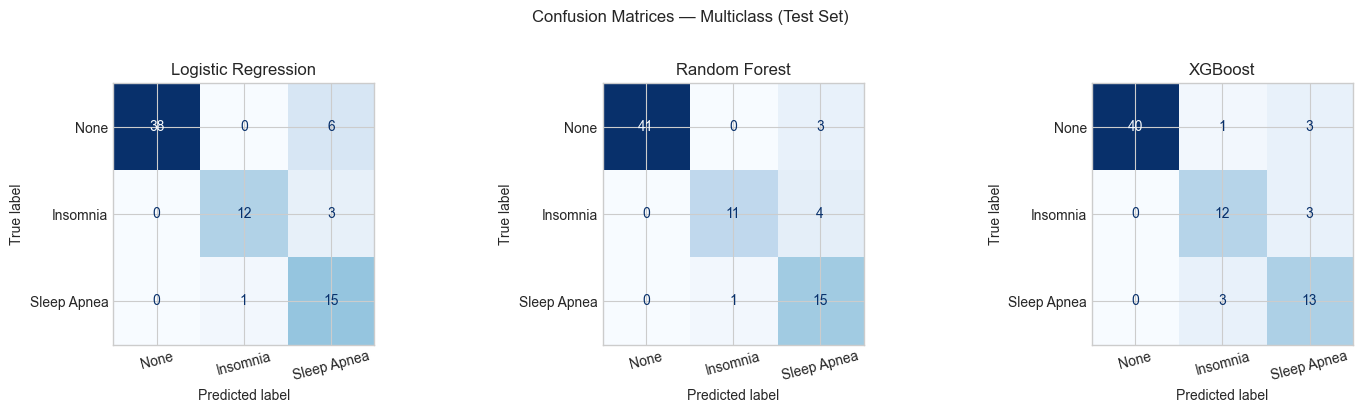

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
class_names = ['None', 'Insomnia', 'Sleep Apnea']

for ax, (name, pred) in zip(axes, [
    ('Logistic Regression', lr_multi_pred),
    ('Random Forest', rf_multi_pred),
    ('XGBoost', xgb_multi_pred),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_multi_test, pred),
        display_labels=class_names
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrices — Multiclass (Test Set)', y=1.02)
plt.tight_layout()
plt.show()

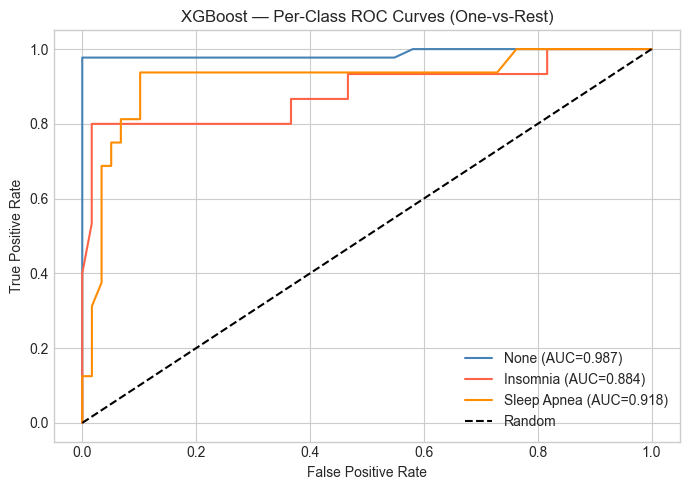

In [39]:
# Per-class ROC curves (XGBoost, One-vs-Rest) 
fig, ax = plt.subplots(figsize=(7, 5))
palette = ['steelblue', 'tomato', 'darkorange']

for i, (label, color) in enumerate(zip(class_names, palette)):
    # Binarize: class i vs all others
    y_bin_ovr = (y_multi_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_bin_ovr, xgb_multi_prob[:, i])
    auc = roc_auc_score(y_bin_ovr, xgb_multi_prob[:, i])
    ax.plot(fpr, tpr, color=color, label=f'{label} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('XGBoost — Per-Class ROC Curves (One-vs-Rest)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
# Multiclass summary table 
multi_results = [
    ('Logistic Regression', lr_multi_pred, lr_multi_prob, lr_multi_roc),
    ('Random Forest', rf_multi_pred, rf_multi_prob, rf_multi_roc),
    ('XGBoost', xgb_multi_pred, xgb_multi_prob, xgb_multi_roc),
]

rows = []
for name, pred, prob, roc in multi_results:
    rows.append({
        'Model': name,
        'F1 Macro': f1_score(y_multi_test, pred, average='macro'),
        'F1 Weighted': f1_score(y_multi_test, pred, average='weighted'),
        'ROC-AUC (macro OvR)': roc,
    })

print('Multiclass Classification Results:')
pd.DataFrame(rows).set_index('Model').round(4)

Multiclass Classification Results:


,F1 Macro,F1 Weighted,ROC-AUC (macro OvR)
Model,,,
Logistic Regression,0.8447,0.8752,0.9482
Random Forest,0.8563,0.8973,0.9397
XGBoost,0.8231,0.8720,0.9298


### B.5 Multiclass — Cross-Validation

In [41]:
# CV on multiclass with macro F1 and ROC-AUC (OvR)
cv_xgb_multi = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', random_state=RANDOM_STATE, verbosity=0
)

cv_f1_multi  = cross_val_score(cv_xgb_multi, X_train, y_multi_train, cv=cv,
                                scoring='f1_macro', n_jobs=-1)
cv_roc_multi = cross_val_score(cv_xgb_multi, X_train, y_multi_train, cv=cv,
                                scoring='roc_auc_ovr_weighted', n_jobs=-1)

print('[Multiclass] 5-Fold CV — XGBoost')
print(f'  F1 Macro:         {cv_f1_multi.mean():.4f} ± {cv_f1_multi.std():.4f} | Folds: {cv_f1_multi.round(4)}')
print(f'  ROC-AUC (OvR wt): {cv_roc_multi.mean():.4f} ± {cv_roc_multi.std():.4f} | Folds: {cv_roc_multi.round(4)}')

[Multiclass] 5-Fold CV — XGBoost
  F1 Macro:         0.8858 ± 0.0410 | Folds: [0.881  0.8603 0.9182 0.8269 0.9424]
  ROC-AUC (OvR wt): 0.9072 ± 0.0481 | Folds: [0.8697 0.8355 0.9686 0.9234 0.9386]


## 8. Feature Importance

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (model, title) in zip(axes, [
    (xgb_bin_model, 'XGBoost — Binary Task'),
    (xgb_multi, 'XGBoost — Multiclass Task'),
]):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Top 15 Feature Importances\n{title}')
    ax.set_xlabel('Importance (Gain)')

plt.tight_layout()
plt.show()

## 9. Save Models

In [42]:
os.makedirs("models", exist_ok=True)

# Define the new file paths inside the folder
bin_model_path = os.path.join("models", "sleep_binary_xgb.pkl")
multi_model_path = os.path.join("models", "sleep_multiclass_xgb.pkl")
features_path = os.path.join("models", "sleep_feature_names.pkl")

# Save the models and feature list
joblib.dump(xgb_bin_model, bin_model_path)
joblib.dump(xgb_multi, multi_model_path)
joblib.dump(X.columns.tolist(), features_path)

print(f"Saved successfully in 'models/' directory:\n- {bin_model_path}\n- {multi_model_path}\n- {features_path}")


Saved successfully in 'models/' directory:
- models\sleep_binary_xgb.pkl
- models\sleep_multiclass_xgb.pkl
- models\sleep_feature_names.pkl
